# Diagnostics! 

#### Importing functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath("../../"))    # Calling the HorizonFinder.py source code from src
from src.source import axisym

#### Data produced & Plots

In [7]:
# Load data
data = pd.read_csv("./data/horizon_common.csv")
theta = data["theta"].values
h = data["h"].values

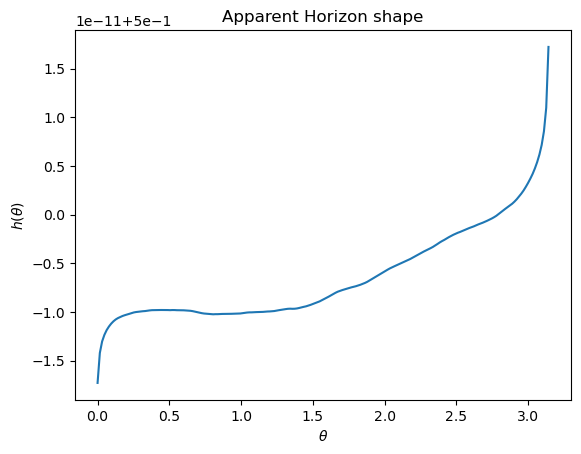

In [8]:
# Plot the surface profile
plt.plot(theta, h)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$h(\theta)$")
plt.title("Apparent Horizon shape")
plt.show()

#### 

In [9]:
# ----- Parameters ----
M = 1.0

# Spatial metric gamma_ij in spherical coordinates (no phi dependance)
def gammaij(r, theta):
    psi = 1 + M/(2*r)
    return np.array([
        [psi**4, 0, 0],
        [0, psi**4 * r**2, 0],
        [0, 0, psi**4 * r**2 * np.sin(theta)**2]
    ])


# Extrinsic curvature (zero in time-symmetric slice)
def Kij(r, theta=None, phi=None):
    return np.zeros((3,3))

#   Create solver instance
solver = axisym(gammaij, Kij)


Solving for horizon ...


In [10]:
# Suppose your class instance is called `solver`
Residual = solver.Horizon(h, theta, dtheta=theta[1] - theta[0])
print(Residual)

[-8.69952312e-08 -6.34553036e-11 -4.76430229e-11  2.08605910e-11
 -7.16701304e-11  1.17183005e-11 -8.73791870e-11 -1.27589603e-10
 -6.03445866e-11 -4.63824833e-11  3.32031218e-11  2.60460874e-11
 -1.77835276e-11  6.39370330e-11  6.77602235e-11 -3.08468736e-12
 -8.86975591e-11 -7.06892024e-11  2.12126702e-11 -3.91439290e-11
 -2.36237354e-11  6.97436390e-11 -3.35513607e-11 -5.99696635e-11
 -1.03419338e-10  7.04253522e-11 -4.64807163e-11 -8.08434094e-11
 -2.51137302e-11  5.98736171e-11  2.50411965e-11  1.61570784e-12
  5.34854518e-11 -9.82019860e-11 -5.51118287e-11  6.47617046e-11
  8.59767461e-11 -1.06959662e-10 -1.08749384e-12  5.79788024e-11
  9.18246466e-12 -3.61236132e-11 -7.05342312e-11 -7.02149061e-11
  6.79506734e-11 -1.04658932e-10  3.66000256e-11  6.37933617e-12
 -3.02139062e-11 -6.23882209e-11  1.32039880e-10  1.01263848e-10
 -6.88218902e-11  1.32853731e-10 -6.69369035e-11 -4.52317072e-11
  4.75381342e-12 -1.09087356e-10  6.46109833e-11  9.24516213e-11
  4.07201709e-11 -6.53715

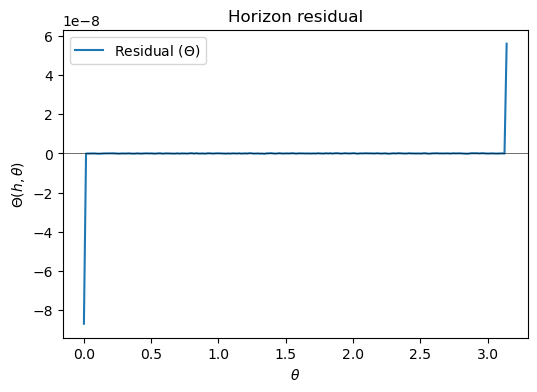

In [11]:
plt.figure(figsize=(6,4))
plt.plot(theta, Residual, label="Residual ($\Theta$)")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\Theta(h,\theta)$")
plt.title("Horizon residual")
plt.axhline(0, color='k', lw=0.4)
plt.legend()
plt.show()